# Lab Exercise 10: Learning the XOR Boolean Function Using an MLP

**Aim**
1. Understand how to implement neural networks using different deep learning libraries (Keras and TensorFlow).
2. Solve the non-linear XOR problem using an MLP, and study how hyperparameters (learning rate, activation function, number of neurons, epochs) affect performance.

**Why a plain perceptron fails:** XOR is *not linearly separable* — you cannot draw a single straight line that separates the `0` outputs from the `1` outputs. A single-layer perceptron can only learn linear boundaries, so it fundamentally cannot solve XOR. An MLP (Multi-Layer Perceptron) adds a hidden layer with a non-linear activation, which lets it bend the decision boundary and solve the problem.



## 0. Setup — Import Libraries

We import TensorFlow/Keras to build and train the networks, NumPy to hold the tiny XOR dataset as arrays, and Matplotlib to plot training curves and decision boundaries. We also fix random seeds so that re-running the notebook gives (nearly) the same results each time.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# fix seeds so results are reproducible across runs
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 1. Create the Dataset

XOR only has 4 possible input combinations, so the entire "dataset" is just these 4 rows.
- `X` holds the two binary inputs for every sample.
- `y` holds the corresponding XOR output.

We use `dtype=np.float32` because TensorFlow's layers expect floating-point inputs, not integers.

In [2]:
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=np.float32)

y = np.array([[0],
              [1],
              [1],
              [0]], dtype=np.float32)

print("Inputs:\n", X)
print("Targets:\n", y)

Inputs:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Targets:
 [[0.]
 [1.]
 [1.]
 [0.]]


# Part A: Keras Implementation

Keras lets us describe the network declaratively, as a stack of layers. We use `Sequential` because our network is a simple feed-forward stack: input -> hidden -> output, with no branching.

## 2. Build the MLP (Keras)

- **Hidden layer:** 4 neurons with `tanh` activation. `tanh` outputs values in [-1, 1] (unlike ReLU, which is 0 for all negative inputs), and that extra flexibility helps a small network like this learn XOR reliably.
- **Output layer:** 1 neuron with `sigmoid` activation, squashing the output into [0, 1] so it can be read as "probability of class 1" — appropriate for binary classification.
- `input_shape=(2,)` tells Keras to expect 2 features per sample (Input 1, Input 2).

In [3]:
keras_model = keras.Sequential([
    layers.Dense(4, activation='tanh', input_shape=(2,), name='hidden_layer'),
    layers.Dense(1, activation='sigmoid', name='output_layer')
])

keras_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. Compile the Model / Define Loss and Optimizer

Compiling attaches the loss function, optimizer, and metrics to the model.
- **Loss:** `binary_crossentropy`, the standard loss for binary classification.
- **Optimizer:** `Adam` with `learning_rate=0.05` — Adam adapts its step size per-parameter, so it converges faster than plain SGD on a tiny problem like this.
- **Metric:** `accuracy`, so we can see exactly when the model starts predicting all 4 XOR cases correctly.

In [4]:
keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.05),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## 4. Train the Model

We train for 500 epochs. `batch_size=4` means every epoch uses all 4 samples at once (full-batch gradient descent) — appropriate since the whole dataset is only 4 rows. `verbose=0` suppresses the per-epoch printout; we keep the returned `history` object instead, so we can plot the loss/accuracy curves afterward.

In [5]:
history = keras_model.fit(X, y, epochs=500, batch_size=4, verbose=0)

print("Final training loss:", history.history['loss'][-1])
print("Final training accuracy:", history.history['accuracy'][-1])

Final training loss: 0.0004920570645481348
Final training accuracy: 1.0


## 5. Evaluate the Model

We run all 4 XOR inputs through the trained model and round the sigmoid output to the nearest integer (0 or 1) to get a hard class prediction. Comparing these against the true XOR outputs confirms whether the network actually learned the function, rather than just minimizing loss without getting every case right.

In [6]:
predictions = keras_model.predict(X, verbose=0)

print("Input      -> Raw output -> Rounded -> Actual")
for i in range(len(X)):
    print(f"{X[i]} -> {predictions[i][0]:.4f}     -> {int(round(predictions[i][0]))}       -> {int(y[i][0])}")

Input      -> Raw output -> Rounded -> Actual
[0. 0.] -> 0.0005     -> 0       -> 0
[0. 1.] -> 0.9993     -> 1       -> 1
[1. 0.] -> 0.9997     -> 1       -> 1
[1. 1.] -> 0.0005     -> 0       -> 0


## 6. Plot Training Curves (Keras)

Plotting loss and accuracy against epoch number shows *how* the network converges, not just the final numbers. For XOR, a healthy training run shows loss dropping toward 0 and accuracy climbing to 1.0 (100%), though it may take a while since XOR's loss surface has flat regions early in training.

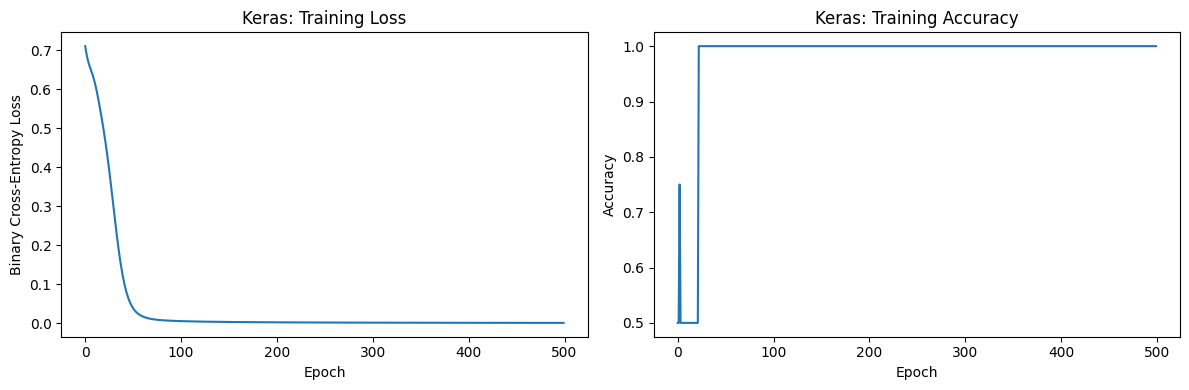

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'])
axes[0].set_title('Keras: Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')

axes[1].plot(history.history['accuracy'])
axes[1].set_title('Keras: Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

## 7. Plot the Decision Boundary (Keras)

We build a fine grid of points covering the input space (from -0.5 to 1.5 on each axis), ask the trained model to predict a value for *every* point on the grid, and color the grid by that predicted value. The 4 real XOR points are overlaid as black-edged markers. If the network has truly learned XOR, you'll see a curved (non-linear) boundary — a straight line could never separate these 4 points correctly, which is exactly why XOR needs a hidden layer.

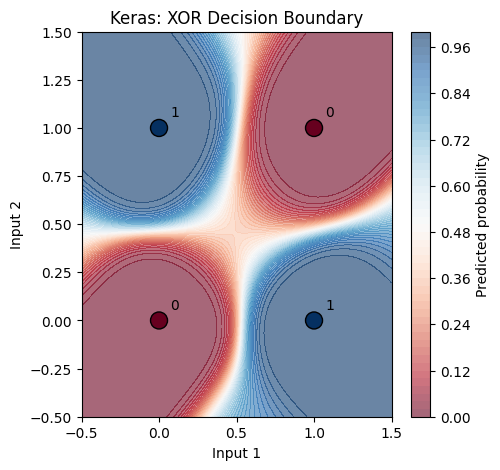

In [8]:
def plot_decision_boundary(predict_fn, title):
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)

    preds = predict_fn(grid).reshape(xx.shape)

    plt.figure(figsize=(5, 5))
    plt.contourf(xx, yy, preds, levels=50, cmap='RdBu', alpha=0.6)
    plt.colorbar(label='Predicted probability')
    plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='RdBu', edgecolors='black', s=150)
    for i in range(len(X)):
        plt.annotate(f"{int(y[i][0])}", (X[i, 0], X[i, 1]), textcoords="offset points", xytext=(8, 8))
    plt.title(title)
    plt.xlabel('Input 1')
    plt.ylabel('Input 2')
    plt.show()

plot_decision_boundary(lambda g: keras_model.predict(g, verbose=0), "Keras: XOR Decision Boundary")

# Part B: TensorFlow Low-Level API

Now we build the *same* network by hand, without Keras layers or `.fit()`. We define the weight and bias tensors ourselves, write the forward pass as explicit matrix multiplications, compute the loss manually, and use `tf.GradientTape` to record operations for automatic differentiation. This is essentially what Keras was doing for us behind the scenes in Part A — seeing it explicitly is the point of this exercise.

## 2B. Define Weights and Biases

`tf.Variable` creates a trainable tensor whose value TensorFlow will update during training.
- `W1`, `b1` — the hidden layer's weights/bias (2 inputs -> 4 hidden neurons).
- `W2`, `b2` — the output layer's weights/bias (4 hidden neurons -> 1 output).

Weights are initialized to small random values (breaking symmetry so neurons learn different things); biases start at zero, which is standard practice.

In [9]:
tf.random.set_seed(42)

# Hidden layer: 2 inputs -> 4 neurons
W1 = tf.Variable(tf.random.normal([2, 4], stddev=0.5), name='W1')
b1 = tf.Variable(tf.zeros([4]), name='b1')

# Output layer: 4 neurons -> 1 output
W2 = tf.Variable(tf.random.normal([4, 1], stddev=0.5), name='W2')
b2 = tf.Variable(tf.zeros([1]), name='b2')

trainable_vars = [W1, b1, W2, b2]

## 3B. Forward Pass and Loss Function

`forward()` performs exactly the same computation as the Keras model:
1. `tanh(X · W1 + b1)` — hidden layer.
2. `sigmoid(hidden · W2 + b2)` — output layer.

`compute_loss()` implements binary cross-entropy by hand: `-(y*log(p) + (1-y)*log(1-p))`, averaged over the batch. `tf.clip_by_value` keeps predictions slightly away from exactly 0 or 1, which prevents `log(0)` (i.e. `NaN`) if the model becomes overconfident.

In [10]:
def forward(x):
    hidden = tf.tanh(tf.matmul(x, W1) + b1)
    output = tf.sigmoid(tf.matmul(hidden, W2) + b2)
    return output

def compute_loss(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
    bce = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))
    return tf.reduce_mean(bce)

## 4B. Define the Optimizer

We use the same `Adam` optimizer and learning rate as Part A, so the two implementations are as directly comparable as possible.

In [11]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.05)

## 5B. Training Loop

There is no `.fit()` here, so we write the training loop ourselves. Each epoch:
1. `tf.GradientTape()` records every operation performed inside its block.
2. We run the forward pass and compute the loss *inside* the tape, so TensorFlow knows which computations to differentiate.
3. `tape.gradient(loss, trainable_vars)` runs backpropagation and returns dLoss/dWeight for every trainable variable.
4. `optimizer.apply_gradients(...)` updates `W1, b1, W2, b2` using those gradients.

We repeat this for 500 epochs (matching Part A) and store loss/accuracy at every step so we can plot them afterward.

In [12]:
X_tf = tf.constant(X)
y_tf = tf.constant(y)

tf_loss_history = []
tf_acc_history = []

epochs = 500
for epoch in range(epochs):
    with tf.GradientTape() as tape:
        preds = forward(X_tf)
        loss = compute_loss(y_tf, preds)

    grads = tape.gradient(loss, trainable_vars)
    optimizer.apply_gradients(zip(grads, trainable_vars))

    rounded = tf.round(preds)
    accuracy = tf.reduce_mean(tf.cast(tf.equal(rounded, y_tf), tf.float32))

    tf_loss_history.append(loss.numpy())
    tf_acc_history.append(accuracy.numpy())

print("Final training loss:", tf_loss_history[-1])
print("Final training accuracy:", tf_acc_history[-1])

Final training loss: 0.0014043475
Final training accuracy: 1.0


## 6B. Evaluate the Model

Same idea as Part A: run the 4 XOR inputs through `forward()` and compare the rounded predictions against the true labels.

In [13]:
tf_predictions = forward(X_tf).numpy()

print("Input      -> Raw output -> Rounded -> Actual")
for i in range(len(X)):
    print(f"{X[i]} -> {tf_predictions[i][0]:.4f}     -> {int(round(tf_predictions[i][0]))}       -> {int(y[i][0])}")

Input      -> Raw output -> Rounded -> Actual
[0. 0.] -> 0.0001     -> 0       -> 0
[0. 1.] -> 0.9974     -> 1       -> 1
[1. 0.] -> 0.9995     -> 1       -> 1
[1. 1.] -> 0.0024     -> 0       -> 0


## 7B. Plot Training Curves (TensorFlow Low-Level)

Same kind of plot as Part A, but using the `tf_loss_history` / `tf_acc_history` lists we filled in manually during the training loop (Keras's `history` object doesn't exist here since we're not using `.fit()`).

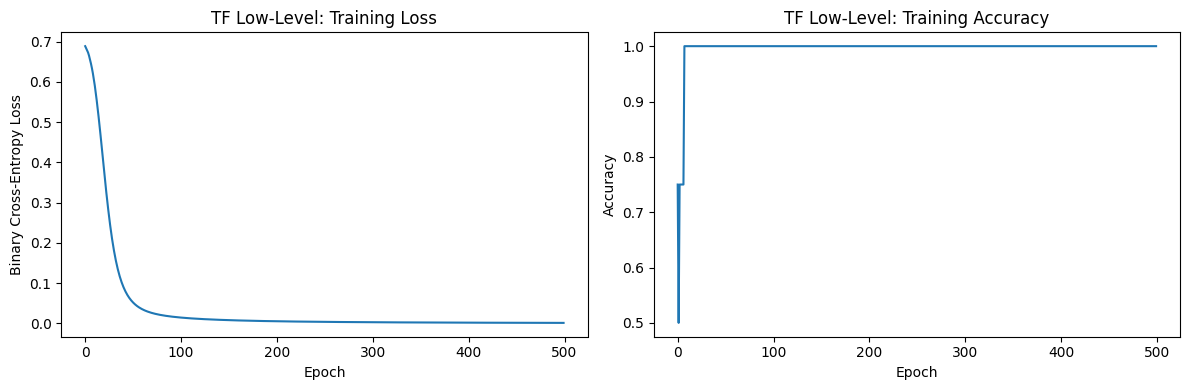

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(tf_loss_history)
axes[0].set_title('TF Low-Level: Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')

axes[1].plot(tf_acc_history)
axes[1].set_title('TF Low-Level: Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

## 8B. Plot the Decision Boundary (TensorFlow Low-Level)

Same grid trick as before, but calling our own `forward()` function instead of `keras_model.predict()`.

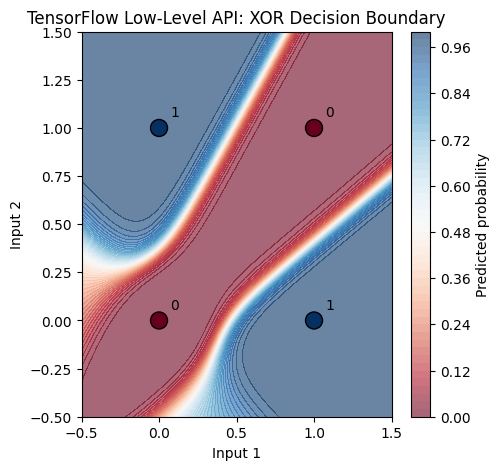

In [15]:
plot_decision_boundary(lambda g: forward(tf.constant(g)).numpy(), "TensorFlow Low-Level API: XOR Decision Boundary")

# Part C: PyTorch Implementation

This satisfies the lab's third-library requirement. PyTorch has no `.compile()`/`.fit()` — like the TensorFlow low-level API, you write the training loop yourself — but it defines the network's *architecture* declaratively with `nn.Sequential`, similar to Keras. So this sits in between Parts A and B in terms of how much is manual.

## 0C. Import PyTorch

`torch` is the core library, `torch.nn` provides layers and loss functions, `torch.optim` provides optimizers. We seed PyTorch's RNG too, for reproducibility.

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

print("PyTorch version:", torch.__version__)

PyTorch version: 2.11.0+cpu


## 1C. Convert the Dataset to Tensors

PyTorch works with `torch.Tensor` objects rather than NumPy arrays or `tf.Tensor`s. `torch.from_numpy` shares the same underlying data as the NumPy array and converts it to PyTorch's tensor type.

In [17]:
X_torch = torch.from_numpy(X)
y_torch = torch.from_numpy(y)

print(X_torch)
print(y_torch)

tensor([[0., 0.],
        [0., 1.],
        [1., 0.],
        [1., 1.]])
tensor([[0.],
        [1.],
        [1.],
        [0.]])


## 2C. Build the MLP (PyTorch)

`nn.Sequential` chains layers together, just like Keras's `Sequential`.
- `nn.Linear(2, 4)` — hidden layer: 2 inputs -> 4 neurons, followed by `nn.Tanh()`.
- `nn.Linear(4, 1)` — output layer: 4 neurons -> 1 output, followed by `nn.Sigmoid()`.

This is architecturally identical to the Keras model in Part A and the manual weights in Part B.

In [18]:
torch_model = nn.Sequential(
    nn.Linear(2, 4),
    nn.Tanh(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

print(torch_model)

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): Tanh()
  (2): Linear(in_features=4, out_features=1, bias=True)
  (3): Sigmoid()
)


## 3C. Define Loss and Optimizer

- **Loss:** `nn.BCELoss()` — binary cross-entropy, matching Parts A and B (it expects inputs already passed through a sigmoid, which is why the model ends with `nn.Sigmoid()` above).
- **Optimizer:** `optim.Adam` with the same `lr=0.05`, over `torch_model.parameters()` (PyTorch's way of collecting every trainable weight/bias in the model).

In [19]:
criterion = nn.BCELoss()
optimizer_torch = optim.Adam(torch_model.parameters(), lr=0.05)

## 4C. Training Loop

PyTorch's training loop follows the same pattern as the TensorFlow low-level loop in Part B, just with different function names:
1. `optimizer_torch.zero_grad()` — clear gradients from the previous step (PyTorch accumulates gradients by default, so this is required every iteration).
2. Forward pass: `torch_model(X_torch)`.
3. `criterion(preds, y_torch)` — compute the loss.
4. `loss.backward()` — backpropagation; PyTorch's autograd computes gradients for every parameter.
5. `optimizer_torch.step()` — apply one gradient-descent update.

We again run 500 epochs and record loss/accuracy at each step.

In [20]:
torch_loss_history = []
torch_acc_history = []

epochs = 500
for epoch in range(epochs):
    optimizer_torch.zero_grad()

    preds = torch_model(X_torch)
    loss = criterion(preds, y_torch)

    loss.backward()
    optimizer_torch.step()

    with torch.no_grad():
        rounded = torch.round(preds)
        accuracy = (rounded == y_torch).float().mean()

    torch_loss_history.append(loss.item())
    torch_acc_history.append(accuracy.item())

print("Final training loss:", torch_loss_history[-1])
print("Final training accuracy:", torch_acc_history[-1])

Final training loss: 0.002285294234752655
Final training accuracy: 1.0


## 5C. Evaluate the Model

Same evaluation pattern as Parts A and B. `torch.no_grad()` tells PyTorch not to track gradients here, since we're only doing inference, not training — this saves memory and computation.

In [21]:
with torch.no_grad():
    torch_predictions = torch_model(X_torch).numpy()

print("Input      -> Raw output -> Rounded -> Actual")
for i in range(len(X)):
    print(f"{X[i]} -> {torch_predictions[i][0]:.4f}     -> {int(round(torch_predictions[i][0]))}       -> {int(y[i][0])}")

Input      -> Raw output -> Rounded -> Actual
[0. 0.] -> 0.0001     -> 0       -> 0
[0. 1.] -> 0.9975     -> 1       -> 1
[1. 0.] -> 0.9975     -> 1       -> 1
[1. 1.] -> 0.0041     -> 0       -> 0


## 6C. Plot Training Curves (PyTorch)

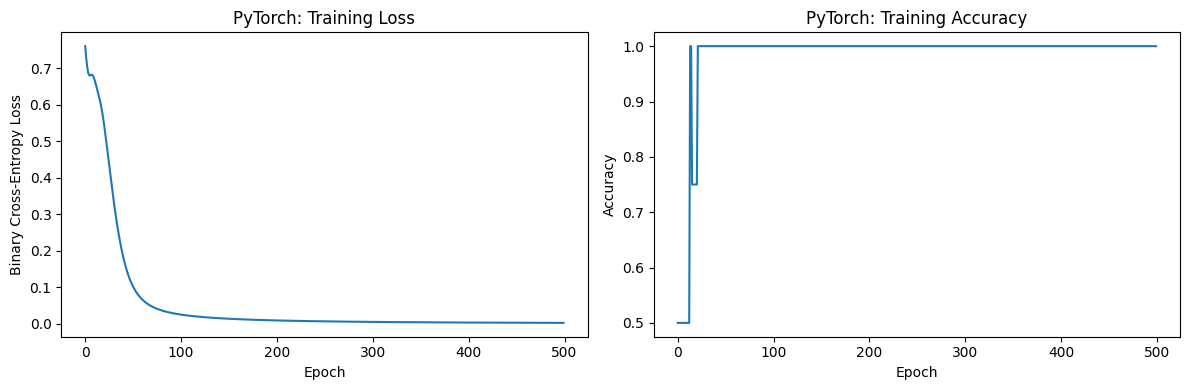

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(torch_loss_history)
axes[0].set_title('PyTorch: Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')

axes[1].plot(torch_acc_history)
axes[1].set_title('PyTorch: Training Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')

plt.tight_layout()
plt.show()

## 7C. Plot the Decision Boundary (PyTorch)

Same grid trick as before. `torch.no_grad()` wraps the prediction since we're only doing inference, and `.numpy()` converts the resulting tensor back so `plot_decision_boundary` (written for NumPy arrays) can use it directly.

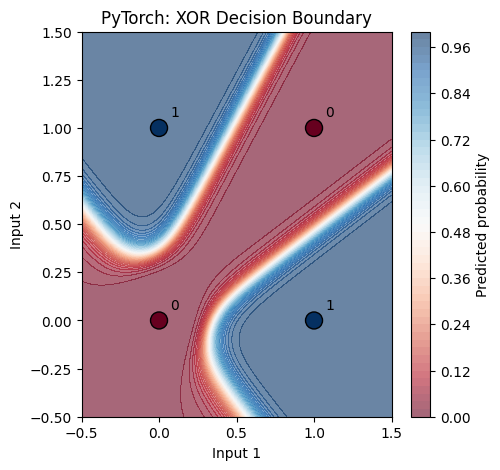

In [23]:
def torch_predict(grid):
    with torch.no_grad():
        return torch_model(torch.from_numpy(grid)).numpy()

plot_decision_boundary(torch_predict, "PyTorch: XOR Decision Boundary")

# Comparison: Keras vs TensorFlow Low-Level vs PyTorch

All three implementations share the same architecture (2 -> 4 -> 1), the same activations (`tanh`, `sigmoid`), the same loss (binary cross-entropy), and the same optimizer (`Adam`, lr=0.05) — so it's fair to plot their training curves on the same axes and compare directly.

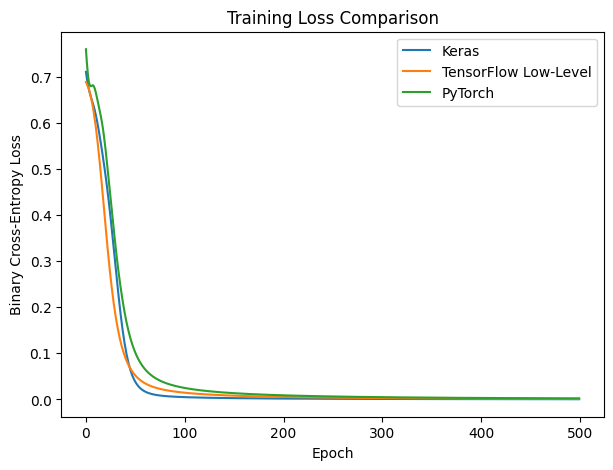

Keras final accuracy:         100.0%
TF low-level final accuracy:  100.0%
PyTorch final accuracy:       100.0%


In [24]:
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='Keras')
plt.plot(tf_loss_history, label='TensorFlow Low-Level')
plt.plot(torch_loss_history, label='PyTorch')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.show()

print(f"Keras final accuracy:         {history.history['accuracy'][-1]*100:.1f}%")
print(f"TF low-level final accuracy:  {tf_acc_history[-1]*100:.1f}%")
print(f"PyTorch final accuracy:       {torch_acc_history[-1]*100:.1f}%")

## Effect of Hyperparameters (Optional Exercise)

A few things worth trying by editing the cell below and re-running:
- **Learning rate:** too high (e.g. > 0.5) can make Adam overshoot and the loss can oscillate instead of settling; too low (e.g. < 0.001) makes training crawl and 300-500 epochs may not be enough.
- **Activation function:** try `relu` instead of `tanh` in the hidden layer. It can still solve XOR, but ReLU's "dead" zone for negative inputs sometimes means you need more neurons or more epochs than `tanh` to reliably converge.
- **Number of hidden neurons:** 2 is the theoretical minimum needed to represent XOR's boundary; going below 2 makes it mathematically impossible to solve, no matter how long you train.
- **Epochs:** too few (e.g. 20-50) leaves the network under-trained — accuracy often gets stuck around 50-75% instead of reaching 100%.

The cell below trains several quick Keras models with different learning rates so you can see the effect directly.

In [25]:
learning_rates = [0.001, 0.01, 0.1, 1.0]

for lr in learning_rates:
    tf.random.set_seed(42)
    model = keras.Sequential([
        layers.Dense(4, activation='tanh', input_shape=(2,)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss='binary_crossentropy', metrics=['accuracy'])
    h = model.fit(X, y, epochs=300, batch_size=4, verbose=0)
    final_acc = h.history['accuracy'][-1]
    print(f"learning_rate={lr:<6} -> final accuracy = {final_acc*100:.1f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


learning_rate=0.001  -> final accuracy = 50.0%
learning_rate=0.01   -> final accuracy = 100.0%
learning_rate=0.1    -> final accuracy = 100.0%
learning_rate=1.0    -> final accuracy = 100.0%


## Conclusion

All three implementations — Keras, TensorFlow low-level, and PyTorch — successfully learn the XOR function once a hidden layer with a non-linear activation (`tanh`) is introduced. This confirms that a single-layer perceptron cannot solve XOR (it can only draw straight-line boundaries), while an MLP with at least one non-linear hidden layer can.

- **Keras** is the most concise: `.compile()` and `.fit()` handle the training loop, gradient computation, and weight updates internally.
- **TensorFlow low-level API** is the most verbose, making every step of backpropagation explicit — the forward pass, the loss calculation, the `GradientTape`, and the manual weight update — which is exactly what's happening inside `.fit()` under the hood.
- **PyTorch** sits in between: the architecture is declared with `nn.Sequential` (Keras-like), but the training loop (`zero_grad` -> forward -> `backward()` -> `step()`) is written by hand, similar in spirit to Part B.

All three models reach (or get very close to) 100% training accuracy and 0/1/1/0 predictions matching the XOR truth table, and their decision-boundary plots all show the same characteristic curved, non-linear separation between the two classes — the three frameworks are different *interfaces* to the same underlying idea.